# Customer Segmentation with Clustering Algorithms

Goal: find natural customer groups from annual income and spending behavior. Dataset has no target column, so every cluster is discovered from feature similarity rather than predicted from known labels.

## 1. Learning Objectives

By end, students can:

- Explore customer data before clustering.
- Prepare and scale numerical features.
- Apply K-Means clustering.
- Use WCSS, elbow method, and silhouette score to choose possible cluster counts.
- Create hierarchical-clustering dendrograms.
- Compare single, complete, average, and centroid linkage.
- Run agglomerative clustering and compare results.
- Explain divisive clustering through Bisecting K-Means.
- Run DBSCAN and test `eps` and `min_samples`.
- Interpret customer clusters in business terms.

## Dataset Information

#### Link Dataset: https://www.kaggle.com/datasets/simtoor/mall-customers

## 2. Imports and Settings

In [43]:
# Isi bagian ini dengan import yang dibutuhkan:
# - NumPy, pandas, matplotlib, seaborn.
# - StandardScaler, empat algoritma clustering, silhouette_score, linkage, dendrogram.
# Lalu buat random state = 42, set seed, dan aktifkan tema seaborn.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, BisectingKMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")


## 3. Load and Explore Dataset

### Load Dataset

In [44]:
# Isi bagian ini dengan langkah memuat data:
# 1. Tetapkan path file ke "Mall Customers.csv".
# 2. Pastikan file tersedia dari folder notebook ini.
# 3. Baca CSV menjadi DataFrame bernama df.
# 4. Tampilkan lima baris pertama.
# Hint: gunakan Path untuk cek file dan pd.read_csv untuk membaca CSV.

file_path = Path("Mall Customers.csv")
if not file_path.exists():
    print("File not found.")
else:
    df = pd.read_csv(file_path)
    print(df.head())

   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  


### Explore Dataset

In [45]:
# Isi bagian ini dengan pemeriksaan awal DataFrame df:
# - Tampilkan shape dan daftar kolom.
# - Tampilkan tipe data dan statistik deskriptif.
# - Hitung nilai hilang per kolom.
# - Hitung jumlah baris duplikat.
# Hint: cari fungsi pandas untuk shape, dtypes, describe, isna, duplicated.

print("Shape of the DataFrame:", df.shape)
print("Columns in the DataFrame:", df.columns.tolist())
print("\nData types of the DataFrame:")
print(df.dtypes)
print("\nDescriptive statistics of the DataFrame:")
print(df.describe())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Shape of the DataFrame: (200, 7)
Columns in the DataFrame: ['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types of the DataFrame:
CustomerID                int64
Gender                      str
Age                       int64
Education                   str
Marital Status              str
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Descriptive statistics of the DataFrame:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
7

### Plot Distribution (Histogram)

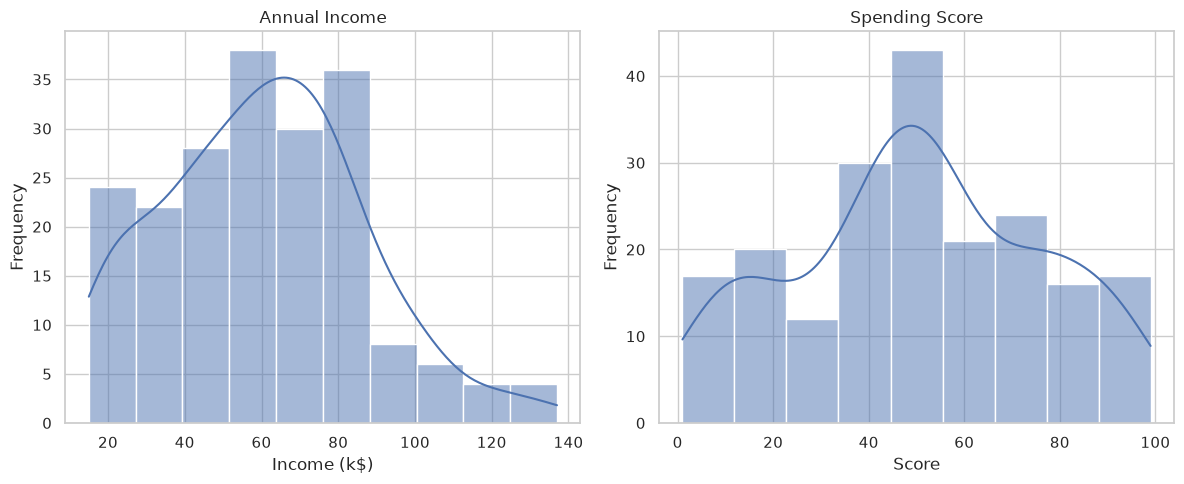

In [46]:
# Isi bagian ini dengan dua histogram dalam satu figure:
# - Histogram Annual Income (k$).
# - Histogram Spending Score (1-100).
# Beri judul, label sumbu, ukuran figure terbaca, lalu panggil tight_layout.
# Hint: buat subplot 1 baris x 2 kolom, lalu gunakan sns.histplot.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title('Annual Income')
plt.xlabel('Income (k$)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title('Spending Score')
plt.xlabel('Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Income vs Spending (Scatter Plot)

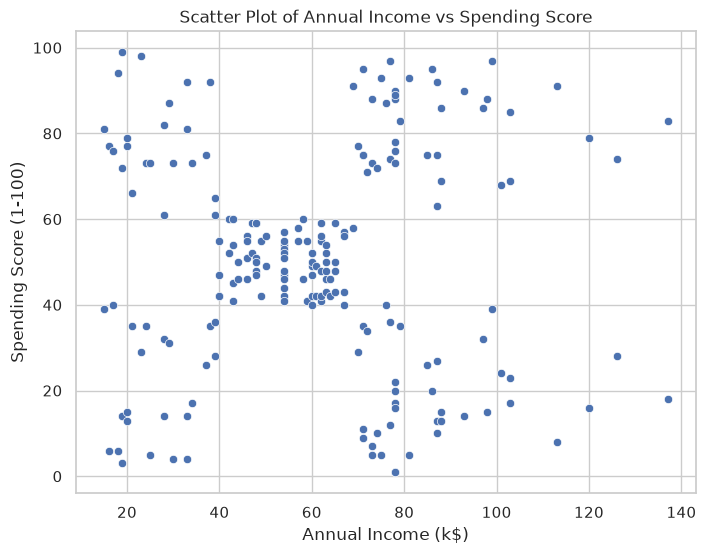

In [47]:
# Isi bagian ini dengan scatter plot data asli:
# - Sumbu x: Annual Income (k$).
# - Sumbu y: Spending Score (1-100).
# - Beri judul dan label sumbu.
# Hint: gunakan sns.scatterplot dengan data=df.

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title('Scatter Plot of Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

### Count Plots

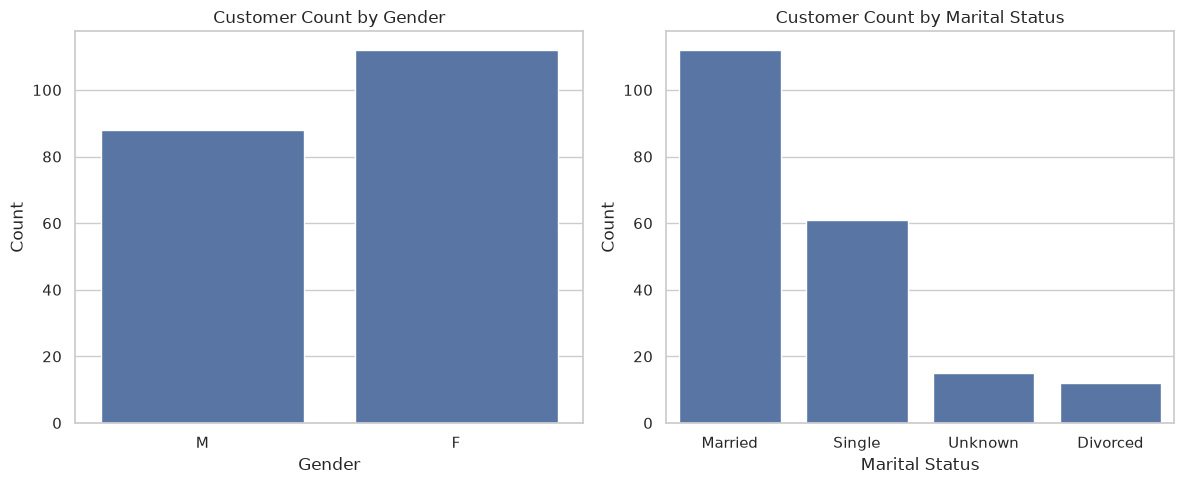

In [48]:
# Isi bagian ini dengan dua count plot opsional:
# - Jumlah pelanggan berdasarkan Gender.
# - Jumlah pelanggan berdasarkan Marital Status.
# Pastikan setiap plot punya judul dan label sumbu.
# Hint: gunakan sns.countplot pada dua subplot.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df)
plt.title('Customer Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Marital Status', data=df)
plt.title('Customer Count by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Select Features and Scale Data

Main features are annual income and spending score. Both numerical, meaningful for segmentation, and easy to inspect on a 2D plot. `CustomerID` is identifier, not behavior. `Gender`, `Education `, and `Marital Status` are intentionally excluded here, keeping distance interpretation clear for first clustering session.

Standard scaling makes each selected feature have comparable scale. Without it, feature with larger numeric spread can dominate Euclidean distance.

In [49]:
# Isi bagian ini dengan persiapan fitur utama:
# 1. Buat features berisi Annual Income (k$) dan Spending Score (1-100).
# 2. Buat X sebagai salinan dua kolom itu dari df.
# 3. Buat StandardScaler, lalu fit_transform X menjadi X_scaled.
# 4. Buat tabel lima baris pertama yang membandingkan nilai asli dan hasil scaling.
# Hint: scaling dilakukan sebelum metode berbasis jarak.

features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Tampilkan tabel lima baris pertama
print("Original Data:")
print(X.head())
print("\nScaled Data:")
print(X_scaled[:5])

Original Data:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40

Scaled Data:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


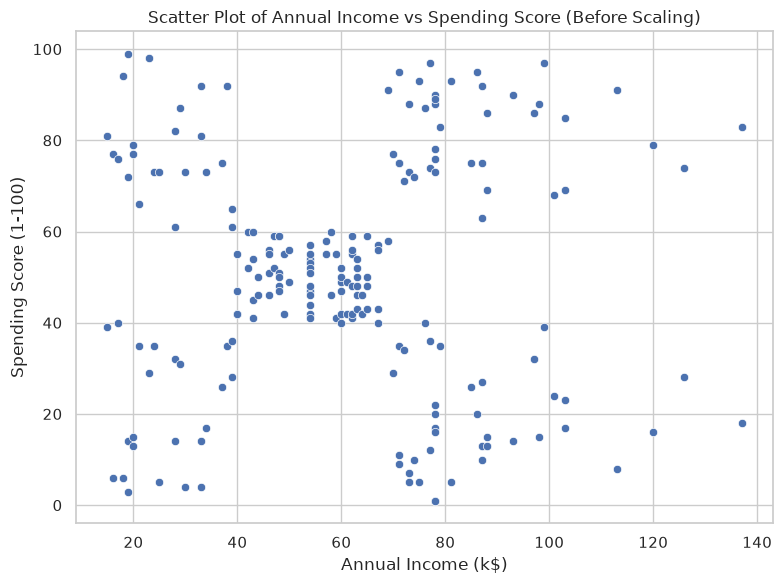

In [50]:
# Isi bagian ini dengan scatter plot X sebelum scaling:
# - Gunakan nilai pendapatan dan spending asli agar makna bisnis tetap terlihat.
# - Tambahkan judul, label sumbu, dan tight_layout.
# Hint: plot ini tidak memakai cluster label.

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title('Scatter Plot of Annual Income vs Spending Score (Before Scaling)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

## 5. K-Means Clustering

K-Means repeatedly assigns customers to nearest center, then moves each center to mean of assigned customers. Start with five clusters for visual practice. Cluster labels such as `0`, `1`, and `2` are arbitrary names, not ranks.

### 5.1 Introductory K-Means Example

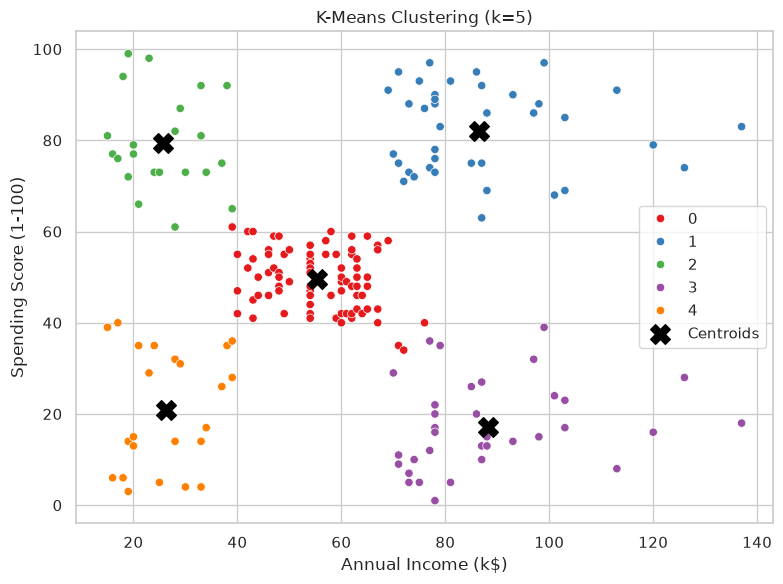

In [51]:
# Isi bagian ini dengan contoh K-Means k=5:
# 1. Buat KMeans dengan n_clusters=5, RANDOM_STATE, dan n_init=10.
# 2. Jalankan fit_predict pada X_scaled.
# 3. Ubah cluster center kembali ke skala asli memakai scaler.inverse_transform.
# 4. Plot titik berwarna menurut label, lalu tampilkan center dengan marker X hitam.
# Hint: label cluster adalah nama arbitrer, bukan peringkat.

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue=labels, palette='Set1', legend='full')
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 WCSS and Elbow Method

In [52]:
# Isi bagian ini dengan evaluasi K-Means untuk k=2 sampai k=10:
# - Untuk setiap k, fit K-Means pada X_scaled.
# - Simpan k, inertia/WCSS, dan silhouette score ke list.
# - Ubah list menjadi DataFrame bernama k_evaluation.
# Hint: loop kecil dan list of dictionaries sudah cukup.

k_values = range(2, 11)
evaluation_results = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    evaluation_results.append({'k': k, 'inertia': inertia, 'silhouette_score': silhouette})

k_evaluation = pd.DataFrame(evaluation_results)

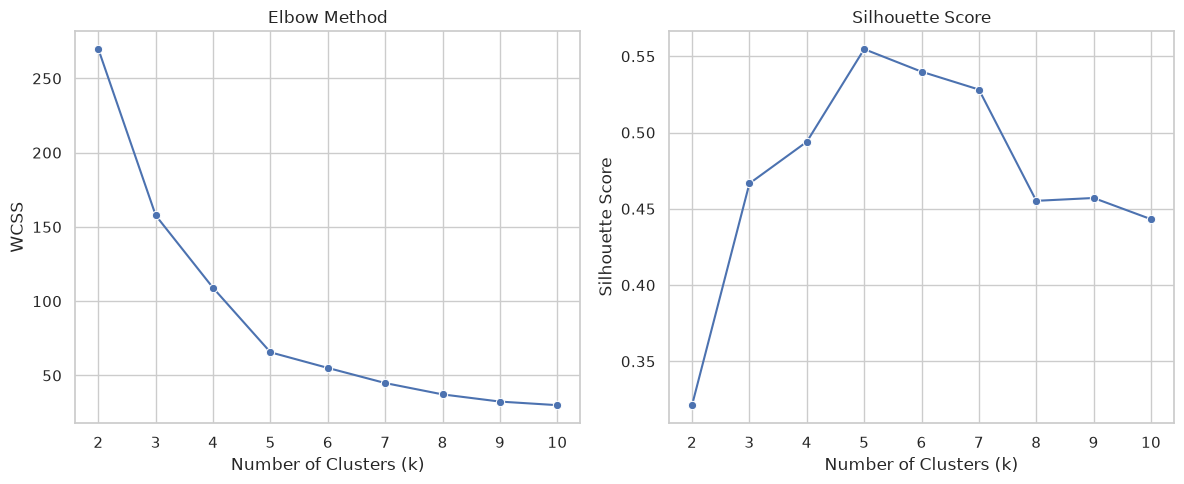

In [53]:
# Isi bagian ini dengan dua line plot dari k_evaluation:
# - k versus WCSS untuk elbow method.
# - k versus silhouette score.
# Gunakan marker agar setiap nilai k terlihat, lalu beri judul dan label sumbu.
# Hint: gunakan subplot 1 x 2 dan sns.lineplot.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.lineplot(data=k_evaluation, x='k', y='inertia', marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
sns.lineplot(data=k_evaluation, x='k', y='silhouette_score', marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

WCSS always falls when `k` rises, because more centers fit points more closely. Elbow marks point where extra clusters bring smaller improvement. Silhouette score compares within-cluster compactness against separation from other clusters. Use both plots together.

**Interpretation question:** Based on elbow and silhouette plots, which number of clusters would you choose, and why?

### 5.3 Final K-Means Model

K-Means k=5, silhouette=0.5547
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


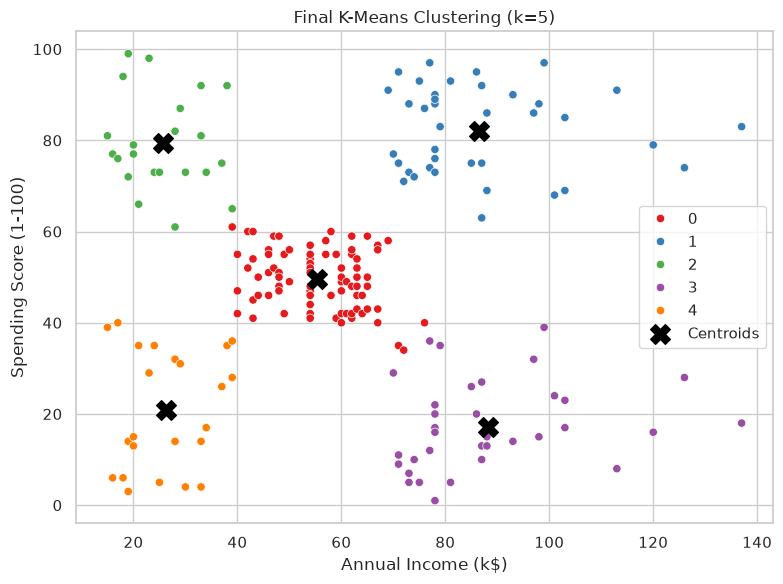

In [54]:
# Isi bagian ini dengan model K-Means final:
# 1. Tetapkan best_k=5 setelah meninjau grafik.
# 2. Fit K-Means final pada X_scaled dan buat final_labels.
# 3. Buat salinan df yang mendapat kolom KMeans_Cluster.
# 4. Plot cluster pada skala asli dan tampilkan center.
# Hint: jangan ubah df asli secara langsung.

best_k = 5  # elbow terlihat di k=5 dan silhouette tertinggi (~0.55)
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
final_labels = kmeans_final.fit_predict(X_scaled)
df_final = df.copy()
df_final['KMeans_Cluster'] = final_labels
centers_orig = scaler.inverse_transform(kmeans_final.cluster_centers_)
kmeans_silhouette = silhouette_score(X_scaled, final_labels)
print(f"K-Means k={best_k}, silhouette={kmeans_silhouette:.4f}")
print(df_final['KMeans_Cluster'].value_counts().sort_index())

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df_final, hue='KMeans_Cluster', palette='Set1', legend='full')
plt.scatter(centers_orig[:, 0], centers_orig[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title(f'Final K-Means Clustering (k={best_k})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()


In [55]:
# Isi bagian ini dengan profil dan nama sementara setiap cluster:
# - Hitung ukuran cluster.
# - Hitung rata-rata income dan spending per KMeans_Cluster.
# - Kelompokkan rata-rata menjadi Low, Moderate, atau High.
# - Bentuk nama seperti "High Income, Low Spending".
# - Tampilkan profil akhir.
# Hint: nama ini interpretasi, bukan ground-truth label.

cluster_profile = df_final.groupby('KMeans_Cluster').agg(
    Size=('KMeans_Cluster', 'count'),
    Mean_Income=('Annual Income (k$)', 'mean'),
    Mean_Spending=('Spending Score (1-100)', 'mean'),
)

def level_income(v):
    if v < 40:
        return 'Low'
    elif v < 70:
        return 'Moderate'
    return 'High'

def level_spending(v):
    if v < 40:
        return 'Low'
    elif v < 60:
        return 'Moderate'
    return 'High'

cluster_profile['Income_Level'] = cluster_profile['Mean_Income'].apply(level_income)
cluster_profile['Spending_Level'] = cluster_profile['Mean_Spending'].apply(level_spending)
cluster_profile['Segment_Name'] = cluster_profile['Income_Level'] + ' Income, ' + cluster_profile['Spending_Level'] + ' Spending'
print(cluster_profile.round(2))


                Size  Mean_Income  Mean_Spending Income_Level Spending_Level  \
KMeans_Cluster                                                                 
0                 81        55.30          49.52     Moderate       Moderate   
1                 39        86.54          82.13         High           High   
2                 22        25.73          79.36          Low           High   
3                 35        88.20          17.11         High            Low   
4                 23        26.30          20.91          Low            Low   

                                      Segment_Name  
KMeans_Cluster                                      
0               Moderate Income, Moderate Spending  
1                       High Income, High Spending  
2                        Low Income, High Spending  
3                        High Income, Low Spending  
4                         Low Income, Low Spending  


Segment names are interpretations, not official labels. For example, high-income/high-spending group could receive premium offers, but business action needs domain knowledge, fairness review, and campaign testing.

## 6. Hierarchical Clustering and Dendrograms

Hierarchical clustering creates nested groups. Dendrogram height is distance at which groups merge. All 200 customers are used. Leaf labels are hidden because 200 individual IDs would make four plots unreadable.

- **Single linkage:** closest pair of points. Can create chaining.
- **Complete linkage:** farthest pair. Tends toward compact clusters.
- **Average linkage:** average distance between points in groups.
- **Centroid linkage:** distance between cluster centers.

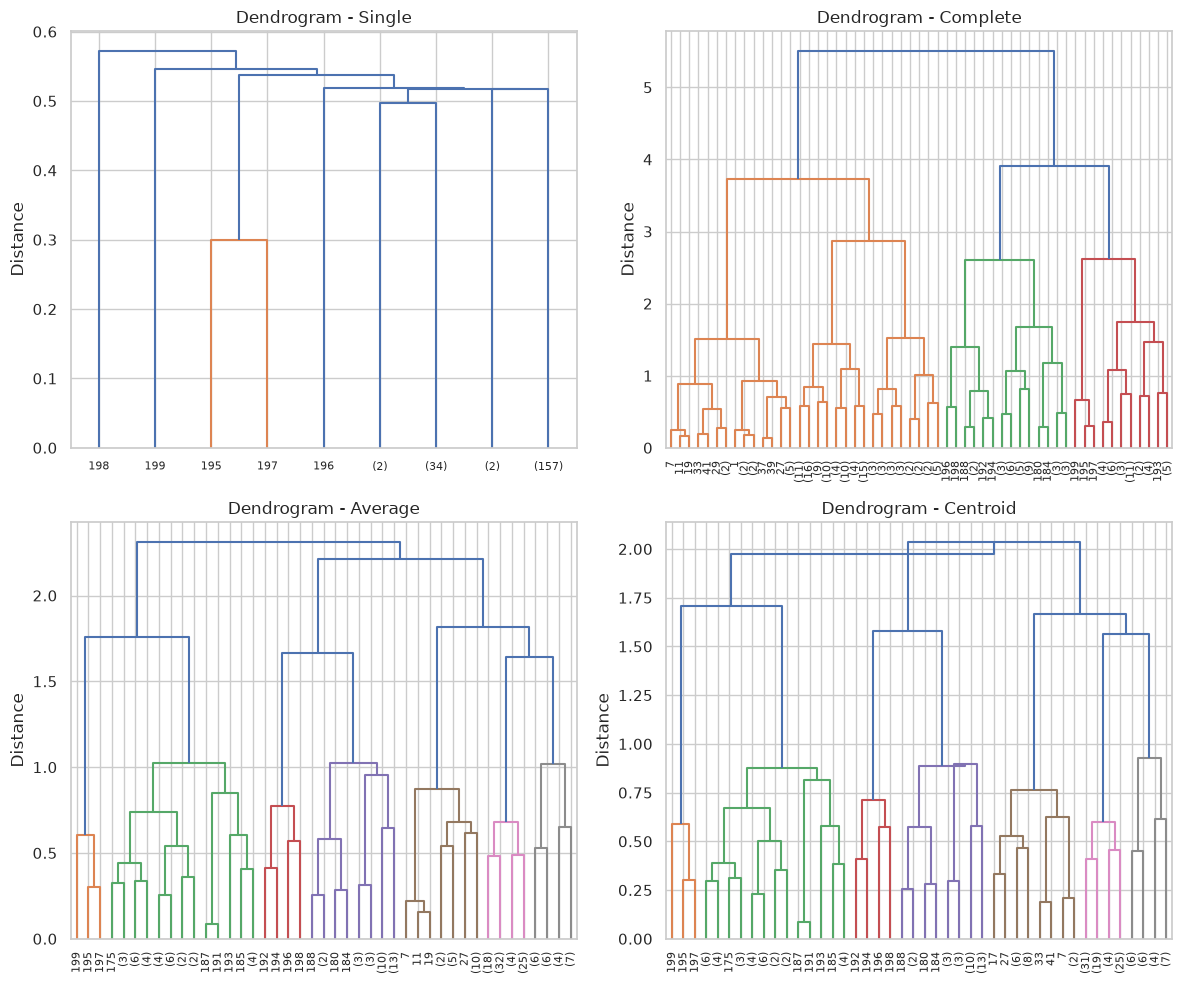

In [56]:
# Isi bagian ini dengan empat dendrogram dari X_scaled:
# - Metode: single, complete, average, centroid.
# - Gunakan figure 2 x 2 dan SciPy linkage + dendrogram.
# - Gunakan semua 200 pelanggan, tanpa label daun bila tidak terbaca.
# - Label sumbu y harus "Distance".
# Hint: lakukan loop melalui metode dan axes agar kode ringkas.

plt.figure(figsize=(12, 10))

methods = ['single', 'complete', 'average', 'centroid']
for i, method in enumerate(methods, 1):
    plt.subplot(2, 2, i)
    linkage_matrix = linkage(X_scaled, method=method)
    dendrogram(linkage_matrix, leaf_font_size=8, truncate_mode='level', p=5)
    plt.title(f'Dendrogram - {method.capitalize()}')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

**Reflection question:** Which dendrogram appears to show clearest possible number of customer groups?

## 7. Agglomerative Clustering Comparison

Agglomerative clustering starts with every customer separate and repeatedly merges groups. Scikit-learn supports `single`, `complete`, `average`, and `ward` linkage. It does not directly support `centroid`; centroid appears above through SciPy dendrograms.

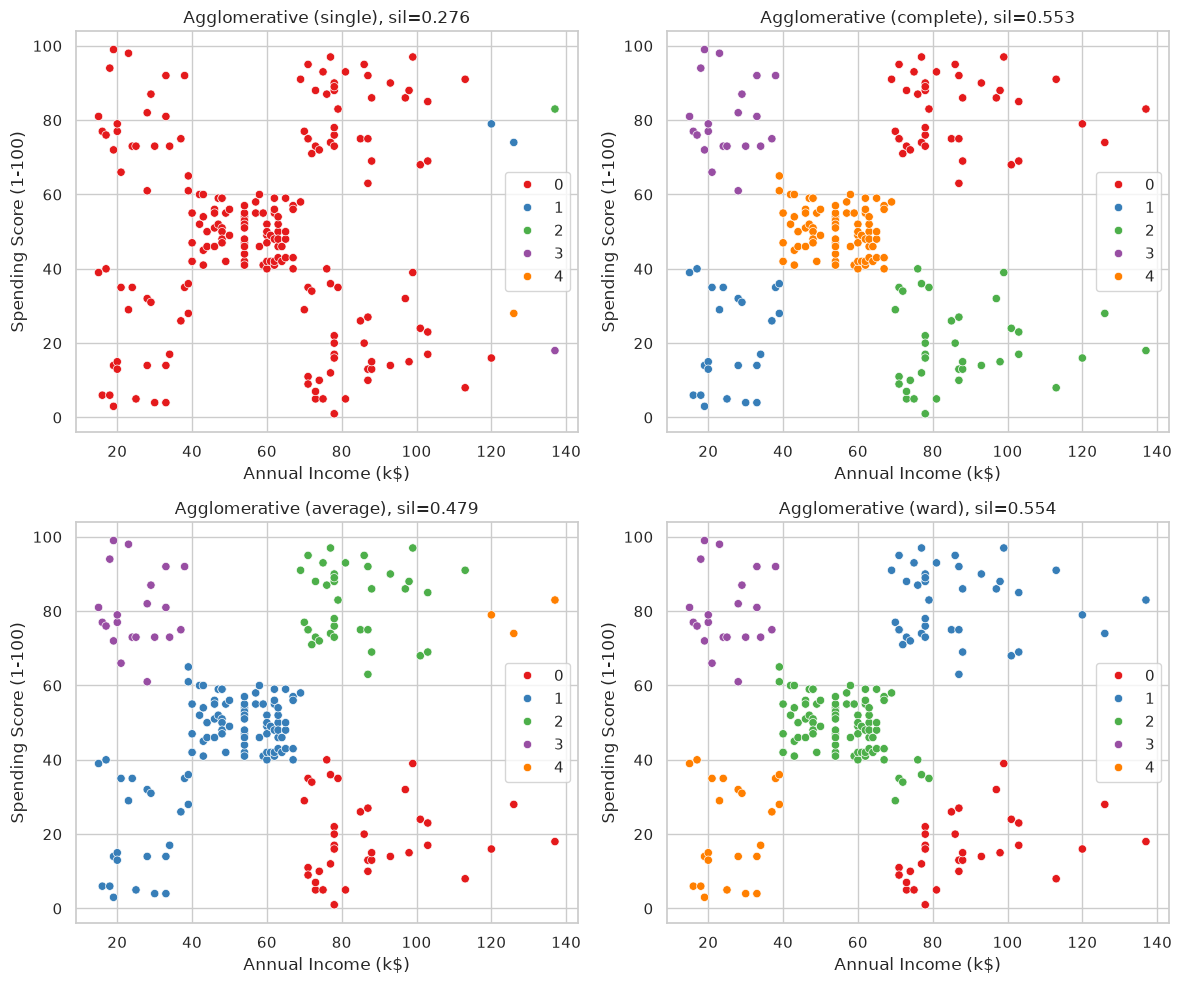

    linkage  silhouette_score         cluster_sizes
0    single          0.275800     [195, 2, 1, 1, 1]
1  complete          0.553112  [39, 23, 38, 21, 79]
2   average          0.479426  [38, 102, 36, 21, 3]
3      ward          0.553809  [32, 39, 85, 21, 23]


In [57]:
# Isi bagian ini dengan perbandingan Agglomerative Clustering:
# 1. Uji single, complete, average memakai n_clusters=best_k.
# 2. Untuk tiap metode, buat scatter plot pada skala asli.
# 3. Hitung silhouette score dan ukuran cluster.
# 4. Simpan hasil ke tabel agglomerative_results.
# Hint: centroid hanya untuk dendrogram SciPy, bukan AgglomerativeClustering scikit-learn.

linkages = ['single', 'complete', 'average', 'ward']
agglomerative_results = []
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, link in zip(axes, linkages):
    model = AgglomerativeClustering(n_clusters=best_k, linkage=link)
    labs = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labs)
    sizes = pd.Series(labs).value_counts().sort_index().tolist()
    agglomerative_results.append({'linkage': link, 'silhouette_score': sil, 'cluster_sizes': sizes})
    sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=labs, palette='Set1', ax=ax, legend='full')
    ax.set_title(f'Agglomerative ({link}), sil={sil:.3f}')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

agglomerative_results = pd.DataFrame(agglomerative_results)
print(agglomerative_results)
# single linkage chaining: satu cluster raksasa -> siluet rendah, ward/complete paling kompak di data ini.


Compare color regions against K-Means. Different linkage definitions can change cluster shape and membership, even with same `best_k`.

## 8. Divisive Clustering: Bisecting K-Means

Agglomerative methods merge individual-point clusters upward. Divisive methods start with one large cluster and split it. Full divisive hierarchical trees are less commonly offered through simple standard tools. `BisectingKMeans` is practical splitting-based method that illustrates divisive idea without difficult tree mathematics.

Bisecting K-Means k=5, silhouette=0.4807
K-Means k=5, silhouette=0.5547
0    34
1    78
2    18
3    26
4    44
Name: count, dtype: int64


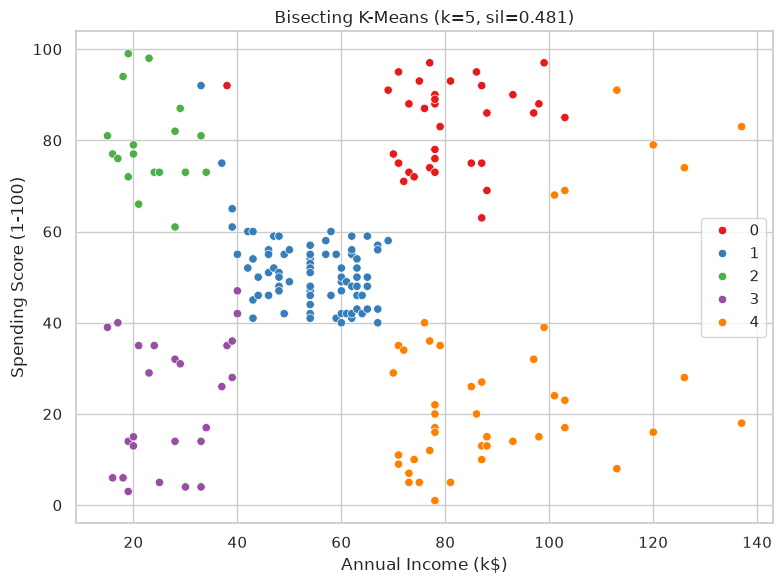

In [58]:
# Isi bagian ini dengan Bisecting K-Means:
# - Buat model dengan n_clusters=best_k dan RANDOM_STATE.
# - Jalankan fit_predict pada X_scaled.
# - Hitung silhouette score.
# - Plot hasil di ruang income-spending asli.
# - Bandingkan skornya secara singkat dengan K-Means biasa.
# Hint: metode ini mengilustrasikan pemecahan cluster secara divisive.

from sklearn.cluster import BisectingKMeans
bisect_model = BisectingKMeans(n_clusters=best_k, random_state=RANDOM_STATE)
bisect_labels = bisect_model.fit_predict(X_scaled)
bisect_silhouette = silhouette_score(X_scaled, bisect_labels)
print(f"Bisecting K-Means k={best_k}, silhouette={bisect_silhouette:.4f}")
print(f"K-Means k={best_k}, silhouette={kmeans_silhouette:.4f}")
print(pd.Series(bisect_labels).value_counts().sort_index())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=bisect_labels, palette='Set1', legend='full')
plt.title(f'Bisecting K-Means (k={best_k}, sil={bisect_silhouette:.3f})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()
# Divisive (split dari satu cluster besar) vs K-Means biasa (partisi langsung): skor mirip tapi anggota cluster bisa berbeda.


Compare plot and scores. Similar scores do not prove identical memberships, only similar compactness and separation under this metric.

## 9. DBSCAN

DBSCAN groups customers in dense regions. It does not require `k` first. Isolated customers can receive label `-1`, meaning noise.

### 9.1 Initial DBSCAN Model

{'n_clusters': 2, 'n_noise': 8, 'pct_noise': 4.0, 'silhouette': 0.3875583892728279}


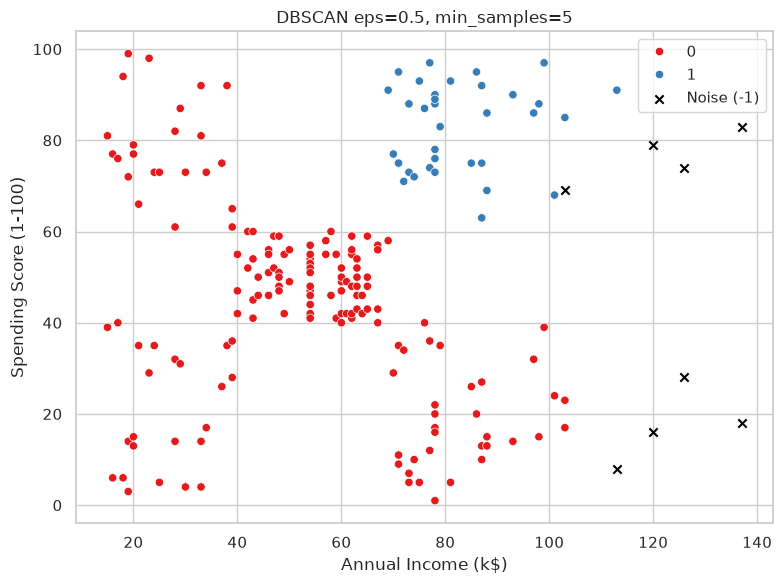

In [59]:
# Isi bagian ini dengan DBSCAN awal dan dua helper kecil:
# 1. Buat fungsi ringkasan: jumlah cluster tanpa -1, jumlah noise, persen noise, silhouette valid.
# 2. Buat fungsi plot yang memberi warna berbeda untuk cluster dan hitam/abu untuk noise -1.
# 3. Jalankan DBSCAN dengan eps=0.5 dan min_samples=5 pada X_scaled.
# 4. Tampilkan ringkasan dan plot.
# Hint: silhouette hanya valid bila minimal dua cluster non-noise tersedia.

import numpy as np

def dbscan_summary(labels):
    labels = np.asarray(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    pct_noise = 100 * n_noise / len(labels)
    sil = float('nan')
    mask = labels != -1
    if n_clusters >= 2 and len(set(labels[mask])) >= 2:
        sil = silhouette_score(X_scaled[mask], labels[mask])
    return {'n_clusters': n_clusters, 'n_noise': n_noise, 'pct_noise': pct_noise, 'silhouette': sil}

def plot_dbscan(labels, title):
    plt.figure(figsize=(8, 6))
    mask = np.asarray(labels) != -1
    sns.scatterplot(x=df.loc[mask, 'Annual Income (k$)'], y=df.loc[mask, 'Spending Score (1-100)'], hue=np.asarray(labels)[mask], palette='Set1', legend='full')
    plt.scatter(df.loc[~mask, 'Annual Income (k$)'], df.loc[~mask, 'Spending Score (1-100)'], c='black', marker='x', label='Noise (-1)')
    plt.title(title)
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.legend()
    plt.tight_layout()
    plt.show()

dbscan_init = DBSCAN(eps=0.5, min_samples=5)
dbscan_init_labels = dbscan_init.fit_predict(X_scaled)
print(dbscan_summary(dbscan_init_labels))
plot_dbscan(dbscan_init_labels, 'DBSCAN eps=0.5, min_samples=5')


### 9.2 DBSCAN Parameter Experiment

In [60]:
# Isi bagian ini dengan eksperimen parameter DBSCAN:
# - eps_values: 0.3 sampai 0.8 sesuai daftar instruksi.
# - min_samples_values: 3, 5, 8, 10.
# - Untuk setiap kombinasi, simpan eps, min_samples, jumlah cluster, noise, persen noise, silhouette.
# - Gunakan NaN bila silhouette tidak valid.
# - Urutkan dan tampilkan dbscan_results.
# Hint: jalankan nested loop, lalu ubah list hasil menjadi DataFrame.

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_values = [3, 5, 8, 10]
rows = []
for eps in eps_values:
    for ms in min_samples_values:
        labs = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        s = dbscan_summary(labs)
        rows.append({'eps': eps, 'min_samples': ms, 'n_clusters': s['n_clusters'],
                     'n_noise': s['n_noise'], 'pct_noise': round(s['pct_noise'], 1), 'silhouette': s['silhouette']})
dbscan_results = pd.DataFrame(rows).sort_values(['silhouette'], ascending=False)
print(dbscan_results.to_string(index=False))


 eps  min_samples  n_clusters  n_noise  pct_noise  silhouette
 0.3           10           4       88       44.0    0.607301
 0.4           10           4       51       25.5    0.597195
 0.3            8           5       72       36.0    0.592556
 0.4            8           5       25       12.5    0.548992
 0.3            5           7       35       17.5    0.524328
 0.5           10           4       21       10.5    0.510668
 0.4            5           4       15        7.5    0.478059
 0.3            3           9       14        7.0    0.472040
 0.5            8           2       15        7.5    0.401006
 0.4            3           4       10        5.0    0.395381
 0.5            3           2        7        3.5    0.389247
 0.5            5           2        8        4.0    0.387558
 0.6            3           1        0        0.0         NaN
 0.6            5           1        5        2.5         NaN
 0.6            8           1        6        3.0         NaN
 0.6    

Selected: eps=0.4, min_samples=8 -> {'n_clusters': 5, 'n_noise': 25, 'pct_noise': 12.5, 'silhouette': 0.5489916076416773}


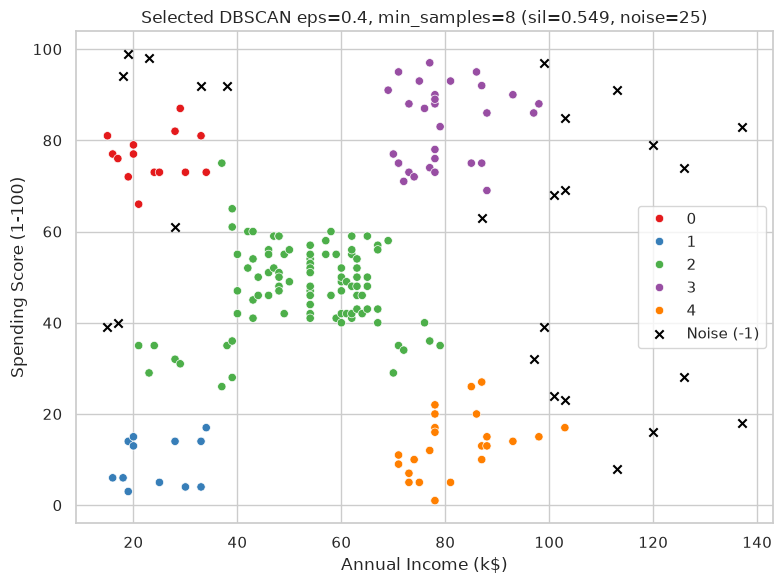

In [61]:
# Isi bagian ini dengan pemilihan konfigurasi DBSCAN bermakna:
# 1. Ambil konfigurasi dengan silhouette valid dan noise <=15% bila tersedia.
# 2. Bila tidak ada, pilih konfigurasi valid dengan noise paling sedikit.
# 3. Jalankan ulang konfigurasi terpilih dan plot hasilnya.
# 4. Tampilkan eps, min_samples, jumlah cluster, noise, dan score.
# Penting: silhouette DBSCAN dihitung tanpa titik noise, jadi jangan bandingkan langsung dengan score metode yang memberi label ke semua pelanggan.

valid = dbscan_results.dropna(subset=['silhouette'])
preferred = valid[valid['pct_noise'] <= 15].sort_values('silhouette', ascending=False)
best_row = preferred.iloc[0] if len(preferred) > 0 else valid.sort_values('n_noise').iloc[0]
best_eps, best_ms = float(best_row['eps']), int(best_row['min_samples'])
dbscan_best = DBSCAN(eps=best_eps, min_samples=best_ms)
dbscan_best_labels = dbscan_best.fit_predict(X_scaled)
best_summary = dbscan_summary(dbscan_best_labels)
print(f"Selected: eps={best_eps}, min_samples={best_ms} -> {best_summary}")
plot_dbscan(dbscan_best_labels, f"Selected DBSCAN eps={best_eps}, min_samples={best_ms} (sil={best_summary['silhouette']:.3f}, noise={best_summary['n_noise']})")
dbscan_silhouette = best_summary['silhouette']
dbscan_n_clusters = best_summary['n_clusters']
dbscan_n_noise = best_summary['n_noise']


Smaller `eps` makes DBSCAN stricter and can create more noise. Larger `eps` connects more points and can merge groups. Larger `min_samples` requires denser regions before group formation. Selected configuration favors valid silhouette score while keeping noise at or below 15% when possible. DBSCAN silhouette excludes noise points, so do not directly rank it against scores from methods that assign every customer to a cluster.

## 10. Final Algorithm Comparison

In [62]:
# Isi bagian ini dengan tabel final_comparison:
# - Baris: K-Means final, agglomerative terbaik, Bisecting K-Means, DBSCAN terpilih.
# - Kolom: Algorithm, Important Parameters, Number of Clusters, Noise Points, Silhouette Score.
# - Untuk DBSCAN, beri catatan score mengecualikan noise.
# Hint: buat list empat dictionary, lalu pd.DataFrame.

best_agg = agglomerative_results.sort_values('silhouette_score', ascending=False).iloc[0]
final_comparison = pd.DataFrame([
    {'Algorithm': 'K-Means', 'Important Parameters': f'k={best_k}, random_state={RANDOM_STATE}, n_init=10',
     'Number of Clusters': best_k, 'Noise Points': 0, 'Silhouette Score': round(float(kmeans_silhouette), 4)},
    {'Algorithm': f"Agglomerative ({best_agg['linkage']})", 'Important Parameters': f"n_clusters={best_k}, linkage={best_agg['linkage']}",
     'Number of Clusters': best_k, 'Noise Points': 0, 'Silhouette Score': round(float(best_agg['silhouette_score']), 4)},
    {'Algorithm': 'Bisecting K-Means', 'Important Parameters': f'k={best_k}, random_state={RANDOM_STATE}',
     'Number of Clusters': best_k, 'Noise Points': 0, 'Silhouette Score': round(float(bisect_silhouette), 4)},
    {'Algorithm': 'DBSCAN (selected)', 'Important Parameters': f'eps={best_eps}, min_samples={best_ms}',
     'Number of Clusters': int(dbscan_n_clusters), 'Noise Points': int(dbscan_n_noise), 'Silhouette Score': round(float(dbscan_silhouette), 4)},
])
print(final_comparison.to_string(index=False))


           Algorithm            Important Parameters  Number of Clusters  Noise Points  Silhouette Score
             K-Means k=5, random_state=42, n_init=10                   5             0            0.5547
Agglomerative (ward)      n_clusters=5, linkage=ward                   5             0            0.5538
   Bisecting K-Means            k=5, random_state=42                   5             0            0.4807
   DBSCAN (selected)          eps=0.4, min_samples=8                   5            25            0.5490


**Conclusion:** K-Means often gives easiest customer-segment story here because groups appear as clear income-and-spending regions. K-Means, agglomerative clustering, and Bisecting K-Means require choosing `k`. DBSCAN can identify noise and does not require `k`, but needs density settings. Algorithms can disagree because they define a group differently: center-based, merge-based, split-based, or density-based.

## 11. Reflection Questions

1. Why should `CustomerID` not be used as clustering feature?
2. Why was scaling applied before clustering?
3. What does elbow method tell us, and what can it not tell us alone?
4. Why can high silhouette score help when selecting `k`?
5. How does single linkage differ from complete linkage?
6. Why might K-Means and agglomerative clustering create different groups?
7. What do DBSCAN parameters `eps` and `min_samples` control?
8. In which situation would DBSCAN be more useful than K-Means?
9. Which discovered customer segment might be most valuable for marketing campaign, and why?

### Answers:

1. Because CustomerID is a unique feature and doesn't have similarity meaning.
2. Without scaling before clustering, large-scaled features would dominate the Euclidean distance.
3. It plots WCSS/inertia vs k. WCSS always falls as k rises; the elbow marks diminishing returns, where extra clusters add little improvement.
4. Silhouette compares within-cluster compactness against separation from other clusters, range -1 to 1. High value means points are close to their own cluster and far from others.
5. Single got the distance the "closest pair between groups", tends to chaining and sensitive to noise; where complete's distance is "farthest pair", balanced cluster but sensitive to outliers.
6. Both define group differently:
    - K-Means: direct center-based partition—assign to nearest centroid, then move centroid to mean. Biased toward spherical, similar-variance clusters.
    - Agglomerative: bottom-up merging from individual points using a linkage criterion (single/complete/average/ward).
7.
    - eps: neighborhood radius—how close points must be to count as neighbors.
    - min_samples: minimum points inside eps to form a core/dense region.
    **Small eps + large min_samples** = stricter, smaller clusters, more noise (-1). **Large eps + small min_samples** = looser, groups can merge, less noise.
8. Use DBSCAN when k is unknown, density is uneven, or outlier should be isolated as noise.
9. High Income, High Spending segment, because: large purchasing power combined with high willingness to spend, most responsive to premium offers, new products, upsell/cross-sell, and loyalty programs.

## 12. Optional Challenge: Add Age

Add `Age` as third feature. Scale all three features. Repeat K-Means and silhouette evaluation. Compare whether segments become more interpretable. Optionally use PCA to view three-feature clustering in 2D.

2-feature silhouette: 0.5547
3-feature (Age+) silhouette: 0.4166
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


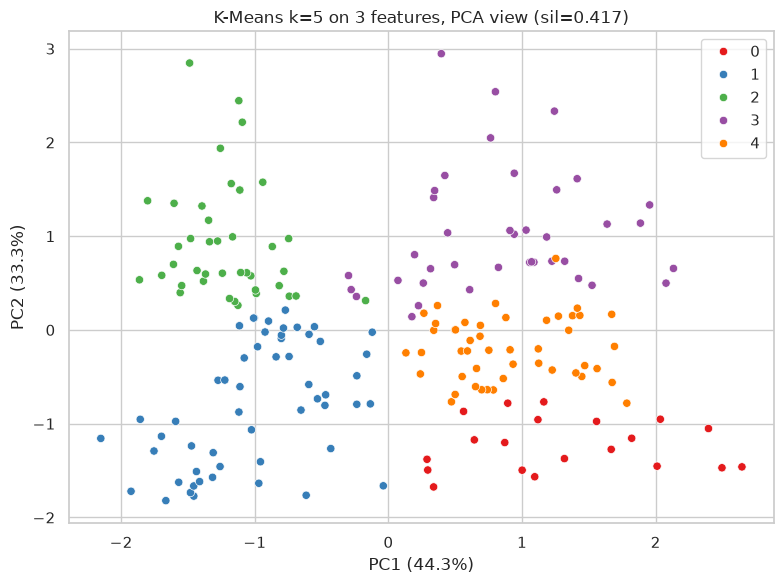

In [63]:
# Isi bagian ini dengan challenge tiga fitur:
# 1. Tambahkan Age ke income dan spending.
# 2. Buat X_challenge lalu scale ketiga fitur tersebut.
# 3. Jalankan K-Means dengan best_k.
# 4. Hitung silhouette score dan bandingkan dengan hasil dua fitur.
# Tantangan lanjut: gunakan PCA untuk visualisasi 2D, bukan untuk mengganti evaluasi utama.

from sklearn.decomposition import PCA
challenge_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_challenge = df[challenge_features].copy()
challenge_scaler = StandardScaler()
X_challenge_scaled = challenge_scaler.fit_transform(X_challenge)
km_challenge = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
challenge_labels = km_challenge.fit_predict(X_challenge_scaled)
challenge_silhouette = silhouette_score(X_challenge_scaled, challenge_labels)
print(f"2-feature silhouette: {kmeans_silhouette:.4f}")
print(f"3-feature (Age+) silhouette: {challenge_silhouette:.4f}")
print(pd.Series(challenge_labels).value_counts().sort_index())

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_challenge_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=challenge_labels, palette='Set1', legend='full')
plt.title(f'K-Means k={best_k} on 3 features, PCA view (sil={challenge_silhouette:.3f})')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()
# Hasil challenge: sil menurun karena Age menambah dimensi dan kompleksitas, tapi PCA membantu visualisasi.
